# Importing data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Data

In [1]:
folder = r"C:\Users\siddh\Downloads\archive (2)"

In [4]:
title_basics = pd.read_csv(folder + r"\title.basics.tsv", sep="\t", low_memory=False)

title_ratings = pd.read_csv(folder + r"\title.ratings.tsv", sep="\t", low_memory=False)

# Merge Both Dataset

In [11]:
df = pd.merge(title_basics, title_ratings, on="tconst", how="inner")

# Check / Understad the Data

In [12]:
df.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",5.7,2213
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short",5.4,319
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance",6.4,2347
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short",5.1,192
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short,6.2,3063


In [13]:
df.tail()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
1684671,tt9916846,tvEpisode,Episode #3.18,Episode #3.18,0,2009,\N,\N,Drama,5.3,7
1684672,tt9916848,tvEpisode,Episode #3.17,Episode #3.17,0,2009,\N,\N,Drama,5.2,7
1684673,tt9916850,tvEpisode,Episode #3.19,Episode #3.19,0,2010,\N,\N,Drama,6.0,7
1684674,tt9916852,tvEpisode,Episode #3.20,Episode #3.20,0,2010,\N,\N,Drama,5.7,7
1684675,tt9916880,tvEpisode,Horrid Henry Knows It All,Horrid Henry Knows It All,0,2014,\N,10,"Adventure,Animation,Comedy",7.6,11


In [14]:
df.columns

Index(['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres', 'averageRating',
       'numVotes'],
      dtype='object')

In [15]:
df.shape

(1684676, 11)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1684676 entries, 0 to 1684675
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   tconst          1684676 non-null  object 
 1   titleType       1684676 non-null  object 
 2   primaryTitle    1684674 non-null  object 
 3   originalTitle   1684674 non-null  object 
 4   isAdult         1684676 non-null  int64  
 5   startYear       1684676 non-null  object 
 6   endYear         1684676 non-null  object 
 7   runtimeMinutes  1684676 non-null  object 
 8   genres          1684672 non-null  object 
 9   averageRating   1684676 non-null  float64
 10  numVotes        1684676 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 141.4+ MB


In [18]:
df.describe()

,isAdult,averageRating,numVotes
count,1.684676e+06,1.684676e+06,1.684676e+06
mean,1.961327e-02,6.967924e+00,1.035133e+03
std,3.114537e+00,1.402038e+00,1.819497e+04
min,0.000000e+00,1.000000e+00,5.000000e+00
25%,0.000000e+00,6.200000e+00,1.200000e+01
50%,0.000000e+00,7.200000e+00,2.600000e+01
75%,0.000000e+00,7.900000e+00,1.000000e+02
max,2.023000e+03,1.000000e+01,3.199593e+06


# Data Cleaning

In [19]:
df.isnull().sum()

tconst            0
titleType         0
primaryTitle      2
originalTitle     2
isAdult           0
startYear         0
endYear           0
runtimeMinutes    0
genres            4
averageRating     0
numVotes          0
dtype: int64

In [20]:
df.isnull().sum().sum()

np.int64(8)

In [21]:
df.notnull().sum()

tconst            1684676
titleType         1684676
primaryTitle      1684674
originalTitle     1684674
isAdult           1684676
startYear         1684676
endYear           1684676
runtimeMinutes    1684676
genres            1684672
averageRating     1684676
numVotes          1684676
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.dropna(inplace = True)

In [24]:
df.nunique()

tconst            1684670
titleType              10
primaryTitle      1239126
originalTitle     1258945
isAdult                 2
startYear             147
endYear                93
runtimeMinutes        759
genres               2081
averageRating          91
numVotes            24537
dtype: int64

In [25]:
df['titleType'].unique()

array(['short', 'movie', 'tvShort', 'tvSeries', 'tvEpisode', 'tvMovie',
       'tvMiniSeries', 'tvSpecial', 'video', 'videoGame'], dtype=object)

In [26]:
df['genres'].unique()

array(['Documentary,Short', 'Animation,Short', 'Animation,Comedy,Romance',
       ..., 'Biography,Horror,Talk-Show', 'Comedy,Mystery,Talk-Show',
       'Music,Musical,Reality-TV'], shape=(2081,), dtype=object)

In [36]:
df.dtypes

tconst             object
titleType          object
primaryTitle       object
originalTitle      object
isAdult             int64
startYear          object
endYear            object
runtimeMinutes     object
genres             object
averageRating     float64
numVotes            int64
dtype: object

# EDA(Exploratory Data Analysis)

In [28]:
df['titleType'].value_counts()

titleType
tvEpisode       865597
movie           346350
short           182248
tvSeries        112579
video            58899
tvMovie          56841
tvMiniSeries     25447
videoGame        19956
tvSpecial        14166
tvShort           2587
Name: count, dtype: int64

In [29]:
df['genres'].value_counts()

genres
Comedy                          131936
Drama                           127860
Documentary                      94392
Action,Adventure,Animation       54899
Reality-TV                       40855
                                 ...  
Documentary,Musical,Thriller         1
Adult,Music,Short                    1
Action,Fantasy,Talk-Show             1
Film-Noir,Horror,Mystery             1
Music,Musical,Reality-TV             1
Name: count, Length: 2081, dtype: int64

In [30]:
df.memory_usage(deep=True)

Index              13477360
tconst             98210574
titleType          95205778
primaryTitle      117419032
originalTitle     118372324
isAdult            13477360
startYear          89286928
endYear            86064610
runtimeMinutes     85969289
genres            106824040
averageRating      13477360
numVotes           13477360
dtype: int64

In [31]:
df['isAdult'].value_counts()

isAdult
0    1659707
1      24963
Name: count, dtype: int64

In [32]:
df[['primaryTitle', 'numVotes']].sort_values(by='numVotes', ascending=False).head(10)

,primaryTitle,numVotes
84610,The Shawshank Redemption,3199593
262354,The Dark Knight,3180373
696238,Inception,2827490
445036,Breaking Bad,2633032
456457,Game of Thrones,2626744
101527,Fight Club,2620235
415705,Interstellar,2547254
83501,Forrest Gump,2504447
84391,Pulp Fiction,2442250
99271,The Matrix,2255038


In [33]:
df[['primaryTitle', 'averageRating']].sort_values(by='averageRating', ascending=False).head(10)

,primaryTitle,averageRating
917296,Gone Golfin',10.0
1498947,Perfect Tattoo,10.0
1066118,The Secret,10.0
1401218,Episode dated 22 January 2001,10.0
1066122,Last Double Swan,10.0
1401219,Episode dated 23 January 2001,10.0
1401220,Episode dated 24 January 2001,10.0
1213603,Mana,10.0
1498942,Episode dated 19 December 1977,10.0
1401189,Episode #2.203,10.0


In [34]:
df['runtimeMinutes'].value_counts()

runtimeMinutes
\N      504320
30       55293
60       51056
22       44137
24       35742
         ...  
1845         1
1682         1
1050         1
1099         1
3600         1
Name: count, Length: 759, dtype: int64

In [35]:
print(df['startYear'].min())
print(df['startYear'].max())

1874
\N


# Data Visualization

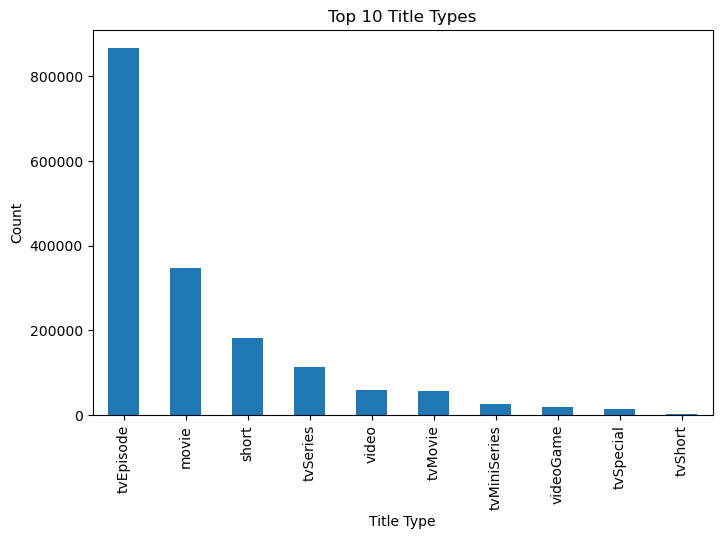

In [37]:
df['titleType'].value_counts().head(10).plot(kind='bar', figsize=(8,5))
plt.title('Top 10 Title Types')
plt.xlabel('Title Type')
plt.ylabel('Count')
plt.show()

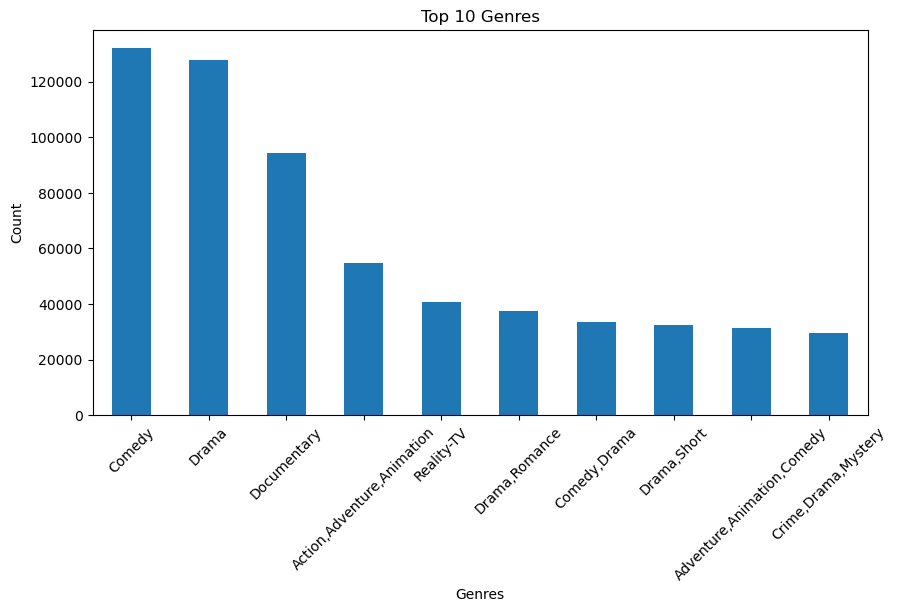

In [38]:
df['genres'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Genres')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

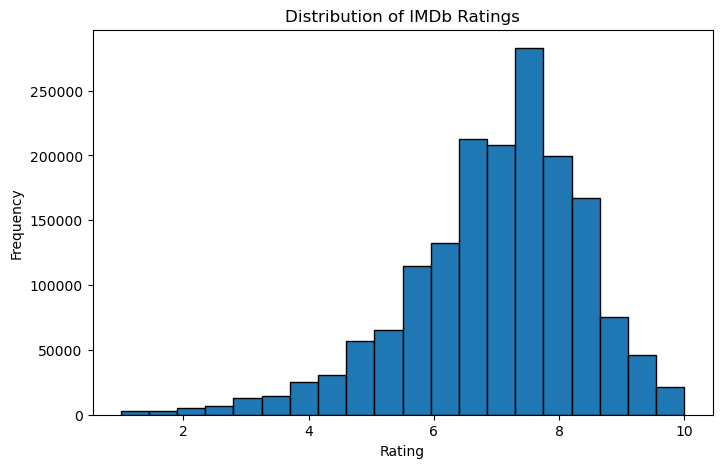

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df['averageRating'].dropna(), bins=20, edgecolor='k')
plt.title('Distribution of IMDb Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

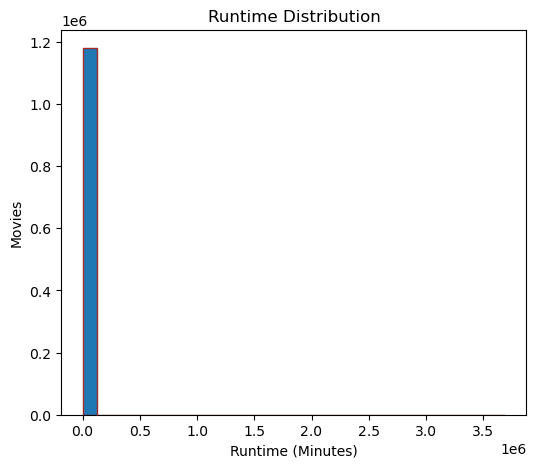

In [42]:
plt.figure(figsize=(6,5))
plt.hist(pd.to_numeric(df['runtimeMinutes'], errors='coerce').dropna(), bins=30, edgecolor='brown')

plt.title('Runtime Distribution')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Movies')
plt.show()

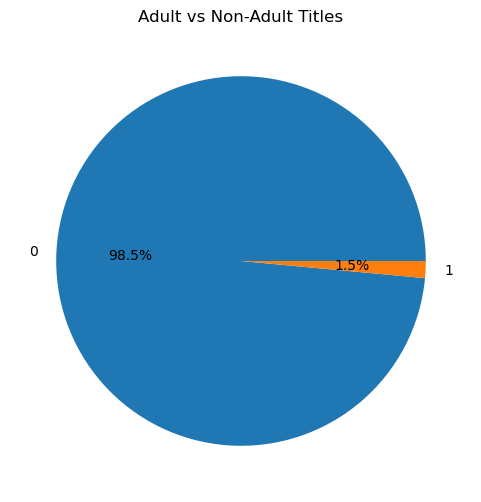

In [47]:
df['isAdult'].value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(6,6))
plt.title('Adult vs Non-Adult Titles')
plt.ylabel('')
plt.show()

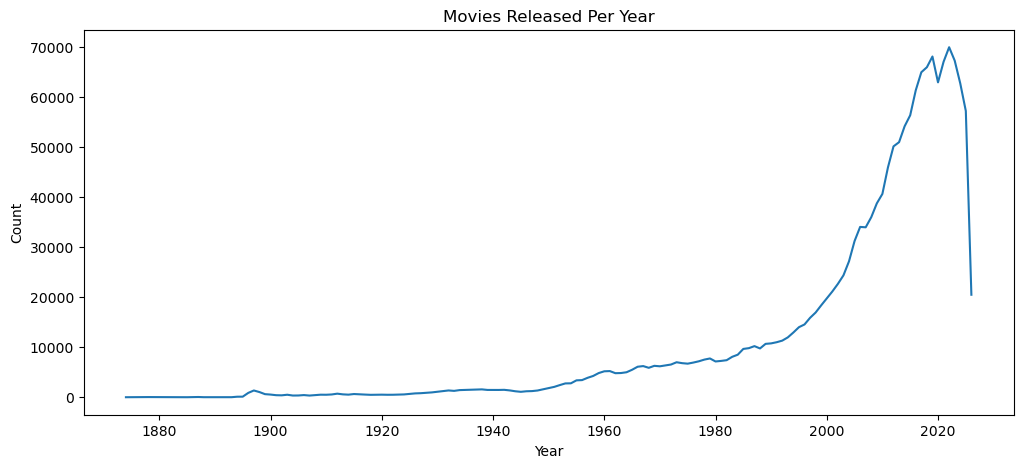

In [48]:
year = pd.to_numeric(df['startYear'], errors='coerce')

year.value_counts().sort_index().plot(figsize=(12,5))
plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

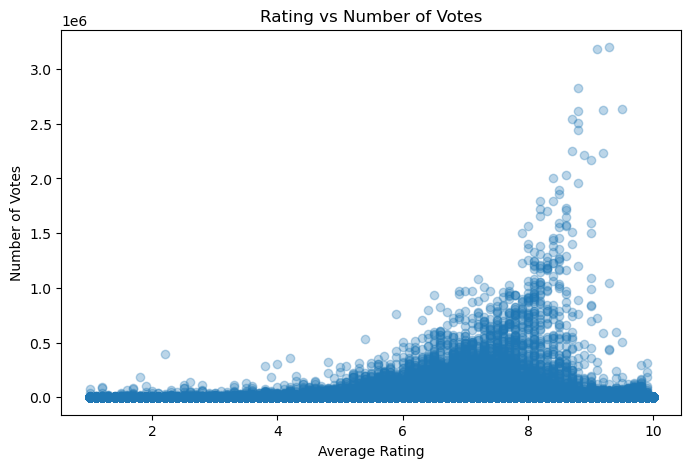

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['averageRating'],
    df['numVotes'],
    alpha=0.3
)
plt.title('Rating vs Number of Votes')
plt.xlabel('Average Rating')
plt.ylabel('Number of Votes')
plt.show()

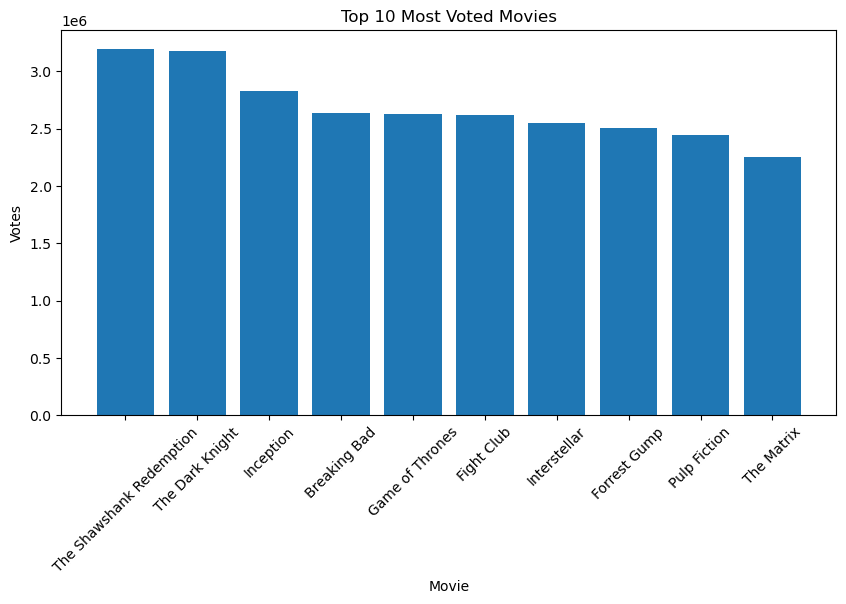

In [53]:
top = df.nlargest(10, 'numVotes')

plt.figure(figsize=(10,5))
plt.bar(top['primaryTitle'], top['numVotes'])
plt.xticks(rotation=45)
plt.title('Top 10 Most Voted Movies')
plt.xlabel('Movie')
plt.ylabel('Votes')
plt.show()

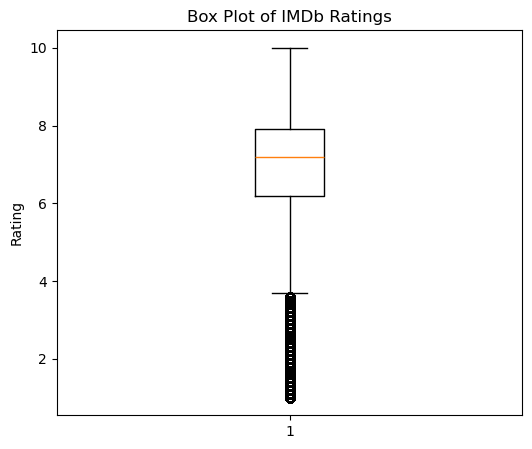

In [51]:
plt.figure(figsize=(6,5))
plt.boxplot(df['averageRating'].dropna())
plt.title('Box Plot of IMDb Ratings')
plt.ylabel('Rating')
plt.show()

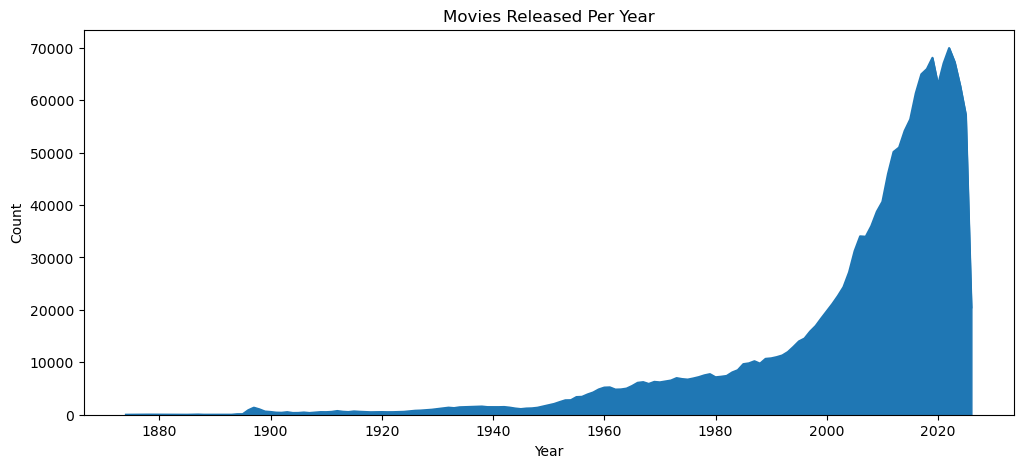

In [57]:
year = pd.to_numeric(df['startYear'], errors='coerce')

year.value_counts().sort_index().plot(
    kind='area',
    figsize=(12,5)
)

plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

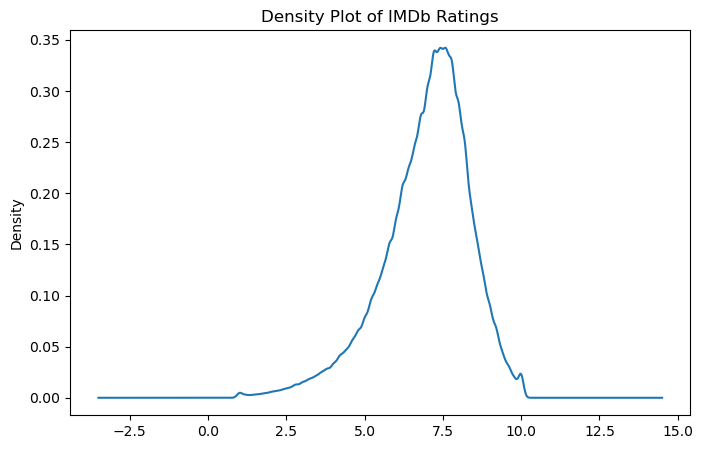

In [58]:
df['averageRating'].plot(
    kind='density',
    figsize=(8,5)
)

plt.title('Density Plot of IMDb Ratings')
plt.show()

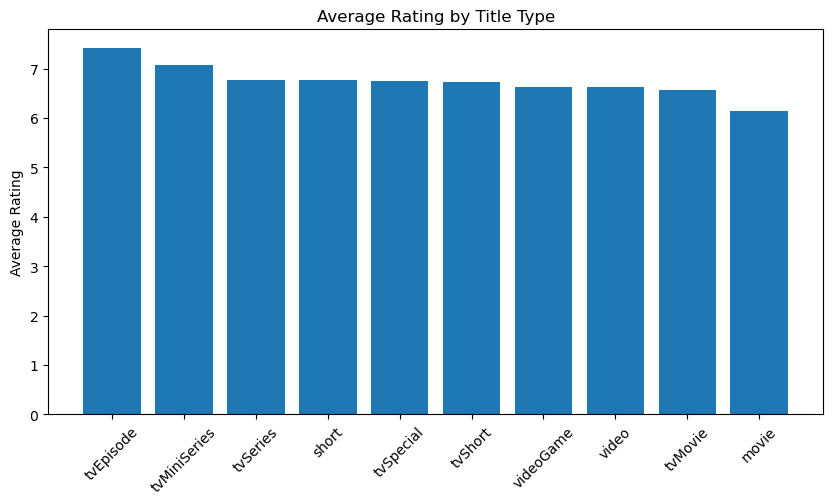

In [59]:
rating = df.groupby('titleType')['averageRating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(rating.index, rating.values)

plt.xticks(rotation=45)
plt.title('Average Rating by Title Type')
plt.ylabel('Average Rating')
plt.show()

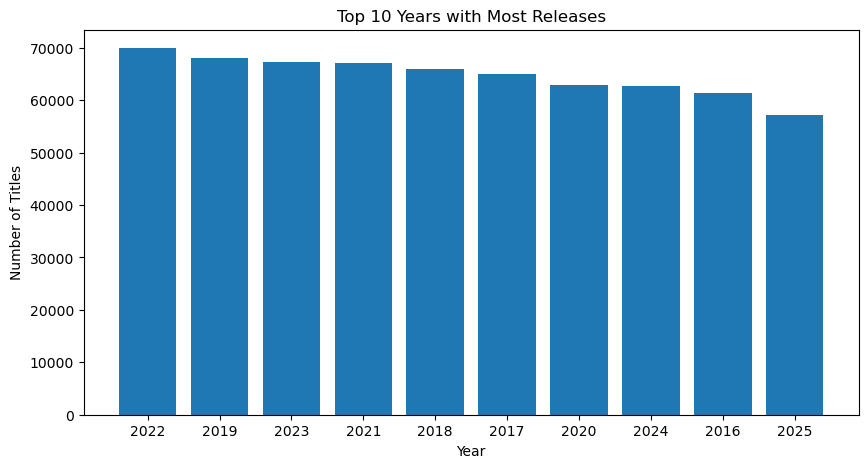

In [60]:
top_years = df['startYear'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_years.index.astype(str), top_years.values)

plt.title('Top 10 Years with Most Releases')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

In [ ]:
year = pd.to_numeric(df['startYear'], errors='coerce')

year.value_counts().sort_index().plot(figsize=(12,5))
plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.